---
layout: post
title: "Pre_studying"
date: 2023-04-25 14:20:00+0800
chap: level_3
---


# Pre studying

对于`GPT`的入门，`karpathy`在`utube`上，上传了简单的[系列讲解视频](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ "video")，在每个视频中，都在`github`上上传了相应的组件代码，用最简单的代码实现，讲解了关于`bp,Transformer`等概念，每个文件也不过几百行代码，但却实现了`bp`等机器学习中的重要概念，是很好的入门`GPT`的资料，所以想要以此为抓手，快速入门
## Back propagation
将全连接神经网络看作一个函数的话，机器学习首要的目的，就是训练参数，使得输出尽可能地接近预期输出
所以很直观地，就需要一个评估输出之间距离的函数，和一个调节参数的方法，所以以下的展开，对应于这两个概念：
- `loss function`
- `gradient decent`
  - ` back bropagation`

如果对于机器学习来说，已知有参数$\theta$ 
$$
\theta^{n + 1} = \theta ^n - \eta \triangle L(\theta ^n)\\
\eta: learning\ rate
$$
而BP，就是对中间层求导数的一个很好的算法，其目的失球损失函数对权重/偏执参数的导数，基本原理是链式求导法则：
$$
\frac{\partial Y}{\partial w} = \frac{\partial Y}{\partial z}\frac{\partial z}{\partial w}
$$
其中`w`是其中一层，对于其输入`x`的系数，`z`是该层的输出，将$\frac{\partial Y}{\partial w}$记为`w.grad`
因为我们只能得到最终输出的数据，对于中间值，则需要递归式地求得不同层下的`gradient`,再进行调整
而对于该层的输出，所有参与到下一层输入中的`z`，使用链式法则算出的梯度，按照权重叠加起来，即为层最后的`grandient`
$$
\frac{\partial Y}{\partial w} = \sum{x_i \frac{\partial Y}{\partial z}}
$$
对于`w`来说，此时的`x`就是他的权重(省略激活函数)
接下来，实现一个简单的可以实现`BP`的类：

In [49]:
class Value:
    def __init__(self,data, child=(),label = '', grad = 0.0,_op = '') -> None:
        self.data = data
        self.grad = grad
        self._op = _op
        self.prev_ = set(child)
        self._backward = None
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, child=(self, other),label= '+',_op = '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
    
        return out
    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data - other.data, child=(self, other),label= '-',_op = '-')

        def _backward():
            self.grad += out.grad
            other.grad -= out.grad
        out._backward = _backward

        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, child=(self, other),label= '*',_op = '*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    
    def __div__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data / other.data, child=(self, other),label= '/',_op = '/')

        def _backward():
            self.grad += out.grad / other.data
            other.grad += out.grad * (-self.data / other.data**2) 
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data ** other.data, child=(self, ),label= '**',_op = '**')

        def _backward():
            self.grad += out.grad * (other.data * self.data**(other.data - 1))
        out._backward = _backward
        return out
    def backward(self):
        topo = [self]
        self.grad = 1.0
        def tran():
            while len(topo) > 0:
                tmp = topo.pop(0)
                for ch in tmp.prev_:
                    topo.append(ch)
                if len(tmp.prev_):
                    tmp._backward()
        tran()
    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out
    
    def __neg__(self):
        return self * -1
    def __radd__(self,other):
        return self + other
    def __rdiv__(self, other):
        return self / other
    def __rmul__(self, other):
        return self * other
    
    def __rsub__(self,other):
        return self - other
    
    

简单地测试一下，上述的代码实现，同样的，采取的是`karpathy`使用的画类流程图的方式：

2072513971272


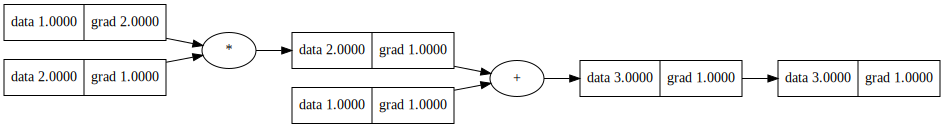

In [50]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev_:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

x = Value(1.0)
y = (x * 2 + 1).relu()
# print(y) 
y.backward()
print(str(id(x)))
draw_dot(y)

基于此，尝试构造多层的神经网络：

In [51]:
import random

class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    def parameters(self):
        return []
    
class Neuron(Module):
    def __init__(self,nin,nonline = True) -> None:
        super().__init__()
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.noline = nonline
    def __call__(self, x) :
        act = sum((wi * xi for wi,xi in zip(self.w,x)),self.b) 
        return act.relu() if self.noline else act
    def parameters(self):
        return self.w + [self.b]
    def __repr__(self) -> str:
        return f"{'ReLU' if self.noline else 'Linear'}Neuron ({len(self.w)})"
class Layer(Module):
    def __init__(self,nin,nout,**kwargs) -> None:
        self.nerons = [Neuron(nin, **kwargs) for _ in range(nout)]
    def __call__(self, x):
        out = [n(x) for n in self.nerons]

        return out[0] if len(out) == 1 else out
    def parameters(self):
        return [p for n in self.nerons for p in n.parameters()]
    def __repr__(self) -> str:
        return f"Layer of [{', '.join(str(n) for n in self.nerons)}]"
class MLP(Module):
    def __init__(self,nins,nouts):
        # print(nins,nouts)
        sz = nins+[nouts]
        self.layers = [Layer(sz[i],sz[i + 1],nonline = i!=(len(nins) - 1)) for i in range(len(nins))]
    
    def __call__(self,x):
        for l in self.layers:
            x = l(x)
        return x
    def parameters(self):  
        return [p for l in self.layers for p in l.parameters()]
    def __repr__(self) -> str:
        return f"MLP of [{', '.join(str(l)for l in self.layers)}]"
    

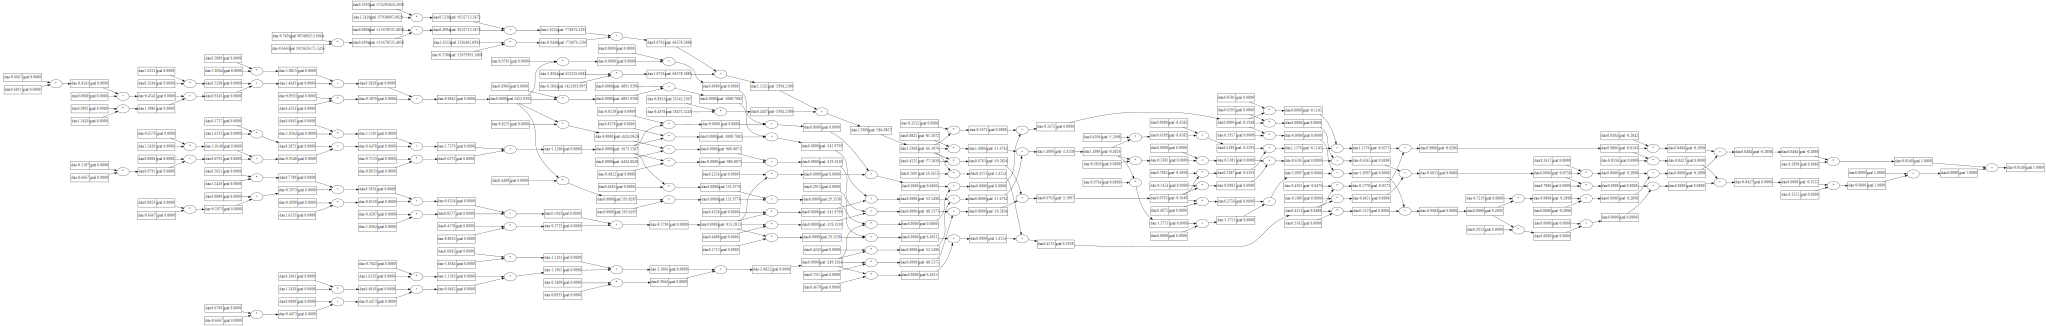

In [52]:
nins = [i + 2 for i in range(5)]
nouts = 1
mlp_test = MLP(list(reversed(nins)),nouts)
x_in = [random.uniform(-2,2) for _ in range(5)]
y_out = mlp_test(x_in)
y_out.backward()
draw_dot(y_out)


在得到这样一个简单的全连接网络之后，以`NLP`的模型为例，尝试搭建简单的模型，尝试构造损失函数，并对参数进行训练
## Bigram
该模型，是以当前字母的下一个字母作为预测结果，来的得到最后的训练效果，以文件夹中的`name.txt`作为输入，先对数据进行处理：

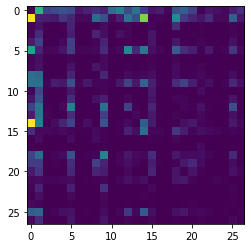

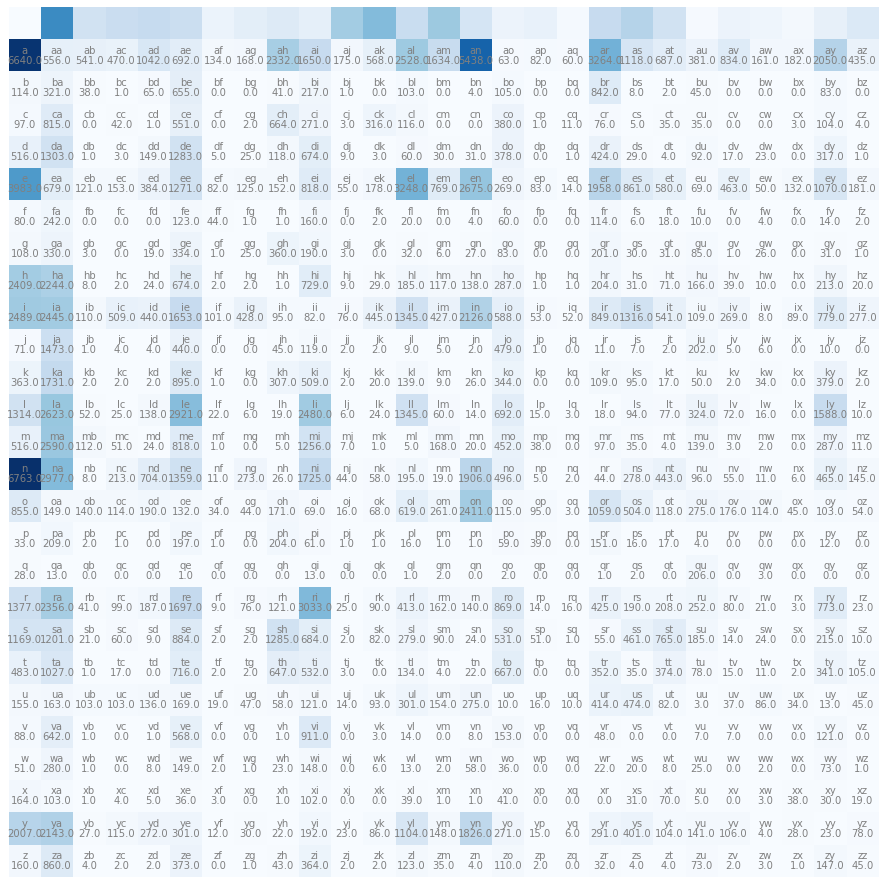

In [53]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
with open ("name.txt","r") as f:
    words = f.read().splitlines()


stoi = {c:i + 1 for i,c in zip(range(26),sorted(list(set(''.join(words)))))}
stoi['*'] = 0
itos = {i:c for c,i in stoi.items()}
# itos
tab = torch.zeros((27,27))
for word in words:
    word = list('*' + word + '*')
    for ch1, ch2 in zip(word,word[1:]):
        row = stoi[ch1]
        line = stoi[ch2]
        tab[row,line] += 1
plt.imshow(tab)
plt.figure(figsize=(16,16))
plt.imshow(tab,cmap='Blues')
for i in range(1,27):
    for j in range(27):
        chstr = itos[i] + (itos[j] if itos[j] != '*' else '')
        plt.text(j,i,chstr, ha = "center",va = "bottom",color = "gray")
        plt.text(j,i,tab[i,j].item(), ha = "center",va = "top",color = "gray")

plt.axis("off")
tab =( tab  + 1)/ tab.sum(1,keepdim=True)

In [54]:
likelihood = 0
for word in words:
    word = list('*' + word + '*')
    prod = 1.0
    for ch1,ch2 in zip(word, word[1:]):
        row = stoi[ch1]
        line = stoi[ch2]
        prob = tab[row,line]
        prod *= prob
    logprob = torch.log(prod)
    logprob = -logprob
    likelihood += logprob
print(f'the likelihood:{likelihood:.4f}')
print(f'the avg likelihood:{likelihood / len(words):.4f}')


the likelihood:559275.0625
the avg likelihood:17.4593


In [55]:
xs , ys = [],[]
for word in words:
    word = list('*' + word + '*')
    for ch1, ch2 in zip(word,word[1:]):
        row = stoi[ch1]
        line = stoi[ch2]
        xs.append(row)
        ys.append(line)
xs = torch.tensor(xs)
ys = torch.tensor(ys) 

x_enc = torch.nn.functional.one_hot(xs,num_classes=27).float()
x_enc.shape
# plt.imshow(x_enc)

torch.Size([228146, 27])

In [56]:
w = torch.randn((27,27),requires_grad=True)

In [57]:
for i in range(500):
    counts = (x_enc @ w).exp()
    probs = counts / counts.sum(1,keepdims = True)
    loss = -probs[torch.arange(len(ys)), ys].log().mean()
    print(f'{i} iter:loss:{loss}')
    w.grad = None
    loss.backward()
    w.data -= 10 * w.grad

0 iter:loss:3.8338582515716553
1 iter:loss:3.735926866531372
2 iter:loss:3.6492090225219727
3 iter:loss:3.5709569454193115
4 iter:loss:3.4997756481170654
5 iter:loss:3.4348561763763428
6 iter:loss:3.375654935836792
7 iter:loss:3.321737051010132
8 iter:loss:3.272702932357788
9 iter:loss:3.2281510829925537
10 iter:loss:3.1876680850982666
11 iter:loss:3.150831937789917
12 iter:loss:3.1172244548797607
13 iter:loss:3.0864510536193848
14 iter:loss:3.058152437210083
15 iter:loss:3.0320184230804443
16 iter:loss:3.007784605026245
17 iter:loss:2.985231876373291
18 iter:loss:2.9641788005828857
19 iter:loss:2.9444754123687744
20 iter:loss:2.925997734069824
21 iter:loss:2.908639669418335
22 iter:loss:2.8923118114471436
23 iter:loss:2.8769376277923584
24 iter:loss:2.8624491691589355
25 iter:loss:2.8487865924835205
26 iter:loss:2.8358969688415527
27 iter:loss:2.8237316608428955
28 iter:loss:2.8122456073760986
29 iter:loss:2.8013970851898193
30 iter:loss:2.791147232055664
31 iter:loss:2.78145885467529

In [58]:
g = torch.Generator().manual_seed(0xdeadbeef)

for i in range(5):
    ix = 0
    out = []
    while True:
        ix_enc = torch.nn.functional.one_hot(torch.tensor([ix]),num_classes=27).float()
        counts = (ix_enc @ w).exp()
        p = counts / counts.sum(1,keepdim=True)
        ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out)) 


aush*
dulissoceliey*
kica*
e*
yqslli*


可以看到，尽管学习率已经设置得不低，但训练起来的速度也并不快，并且最后的学习效果也不尽理想
想要达到更好的效果，就需要增长训练集的字符长度，但会引起训练集的指数级别的增长
其中比较关键的一个思想是，将原来的很高维的数据，进行压缩，相当于一个简单的聚类，以此来渐小数据量，作为降维，来提高训练规模和准确性，算法的细节都在[这篇论文](https://www.youtube.com/redirect?event=video_description&redir_token=QUFFLUhqazBiMEljbjgyaC1mX1ZyYUwyNTA0ZE9RbnJFUXxBQ3Jtc0tsUFJQNzl4Q0ZYVnZPbGh5dFd4LTlEWENiVGdZc0EzazVHbTk3MTRnZWtndWFMa0poU0x1aVVxcEZ6TE9UcjlqVk0yRHd1cFlHU0ozSnYwLVdpQmNzSVBKcjRQVFFlbXVvbmJCOW9ZWjBjR085bUxzSQ&q=https%3A%2F%2Fwww.jmlr.org%2Fpapers%2Fvolume3%2Fbengio03a%2Fbengio03a.pdf&v=TCH_1BHY58I)中

In [65]:
import torch.nn.functional as F
block_size = 4
train_rate = 0.8
val_rate = 0.1
test_rate = 0.1

X,Y = [],[]

def split_dataset(train_rate, val_rate, test_rate, words):
    len_ = len(words)
    n_1 = int(len_ * train_rate)
    n_2 = int(len_ * val_rate) + n_1
    n_3 = int(len_ * test_rate) + n_2
    train_set = words[:n_1]
    val_set = words[n_1:n_2]
    test_set = words[n_2:]

    return [train_set,val_set,test_set]

for word in words:
    context = [0] * block_size
    for ch in word + '*':
        ch = stoi[ch]
        X.append(context)
        Y.append(ch)

        context = context[1:] + [ch]
X = torch.tensor(X)
Y = torch.tensor(Y)
x_train,x_val,x_test = split_dataset(train_rate,val_rate,test_rate,X)
y_train,y_val,y_test = split_dataset(train_rate,val_rate,test_rate,Y)
print(X.dtype,Y.dtype)


torch.int64 torch.int64


In [70]:
batach_size = 64
C = torch.randn((27,10),generator = g)
W_1 = torch.randn((40,400),generator = g)
B_1 = torch.randn(400,generator = g)
W_2 = torch.randn((400,27),generator = g)
B_2 = torch.randn(27,generator = g)
parameters = [C,W_1,B_1,W_2,B_2]
for p in parameters:
    p.requires_grad = True
lossi = []
stepi = []


In [89]:
for i in range(20000):
    ix = torch.randint(0,x_train.shape[0],(batach_size,),generator = g)
    emb = C[x_train[ix]]
    tanh = torch.tanh(emb.view(-1,40)@W_1 + B_1)
    logits = tanh@W_2 + B_2
    loss = F.cross_entropy(logits,y_train[ix])
    for p in parameters:
        p.grad = None

    loss.backward()
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    stepi.append(i)
    lossi.append(loss.log10().item())



The trainset loss:1.9466
The valset loss:2.3839


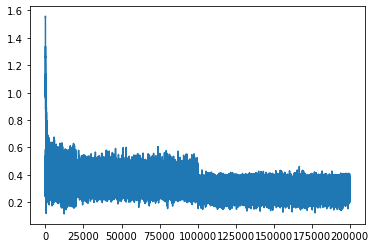

In [90]:
plt.plot(stepi, lossi)
emb = C[x_train] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 40) @ W_1 + B_1) # (32, 100)
logits = h @ W_2 + B_2 # (32, 27)
loss = F.cross_entropy(logits, y_train)
print(f'The trainset loss:{loss:.4f}')


emb = C[x_val] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 40) @ W_1 + B_1) # (32, 100)
logits = h @ W_2 + B_2 # (32, 27)
loss = F.cross_entropy(logits, y_val)
print(f'The valset loss:{loss:.4f}')


In [91]:
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W_1 + B_1)
      logits = h @ W_2 + B_2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

brycen*
oaklendoa*
yamana*
vadiel*
tulamia*
meniah*
onanahni*
tzifusriah*
jacou*
floro*
yirr*
penner*
saminellum*
jakpibdalynn*
resley*
jayannah*
dinna*
mileen*
amaya*
mara*
